In [12]:
from pprint import pprint
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
import numpy as np

from dolphin.processor.config import ModelConfig
from dolphin.processor import Processor
from dolphin.analysis.output import Output

In [13]:
processor = Processor("../io_directory_example/")

lens_name = "lens_system2"
model_id = "example"
reconstruction_id = "recon_v3"

In [14]:
# processor.swim(lens_name=lens_name, model_id=model_id, log=False)

In [15]:
output = Output("../io_directory_example/")

output.load_output(lens_name=lens_name, model_id=model_id)
kwargs_lens = output.kwargs_result["kwargs_lens"]
print("Lens center:", kwargs_lens[0].get("center_x"), kwargs_lens[0].get("center_y"))

# Then set source grid to be centered there
lens_center_x = kwargs_lens[0].get("center_x", 0)
lens_center_y = kwargs_lens[0].get("center_y", 0)
grid_half_width = 1.2  # arcsec, adjust as needed

pixel_size = 0.04  # arcsec
grid_pixels = int((grid_half_width * 2) / pixel_size)

print(f'Using source grid of size {grid_pixels}x{grid_pixels} pixels, pixel size {pixel_size} arcsec')

Lens center: 0.03203556488887021 -0.03930654885858535
Using source grid of size 60x60 pixels, pixel size 0.04 arcsec


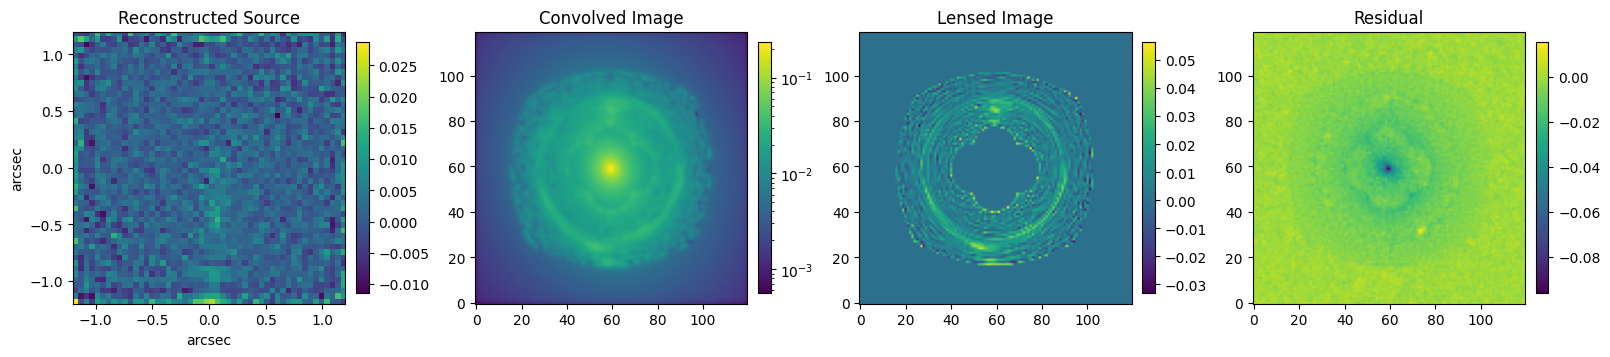

In [16]:
result = output.load_reconstruction_output(lens_name=lens_name, reconstruction_id=reconstruction_id)

_, ax = plt.subplots(1, 4, figsize=(16, 4), constrained_layout=True)

im0 = ax[0].imshow(result["source_image"], origin='lower', extent=[-grid_half_width, grid_half_width, -grid_half_width, grid_half_width])
ax[0].set_title("Reconstructed Source")
ax[0].set_xlabel("arcsec")
ax[0].set_ylabel("arcsec")
plt.colorbar(im0, ax=ax[0], fraction=0.046, pad=0.04)

im1 = ax[1].imshow(result["convolved_image"], origin='lower', norm=LogNorm())
ax[1].set_title("Convolved Image")
plt.colorbar(im1, ax=ax[1], fraction=0.046, pad=0.04)

im2 = ax[2].imshow(result["lensed_image"], origin='lower')
ax[2].set_title("Lensed Image")
plt.colorbar(im2, ax=ax[2], fraction=0.046, pad=0.04)

im3 = ax[3].imshow(result["residual"], origin='lower')
ax[3].set_title("Residual")
plt.colorbar(im3, ax=ax[3], fraction=0.046, pad=0.04)

plt.show()

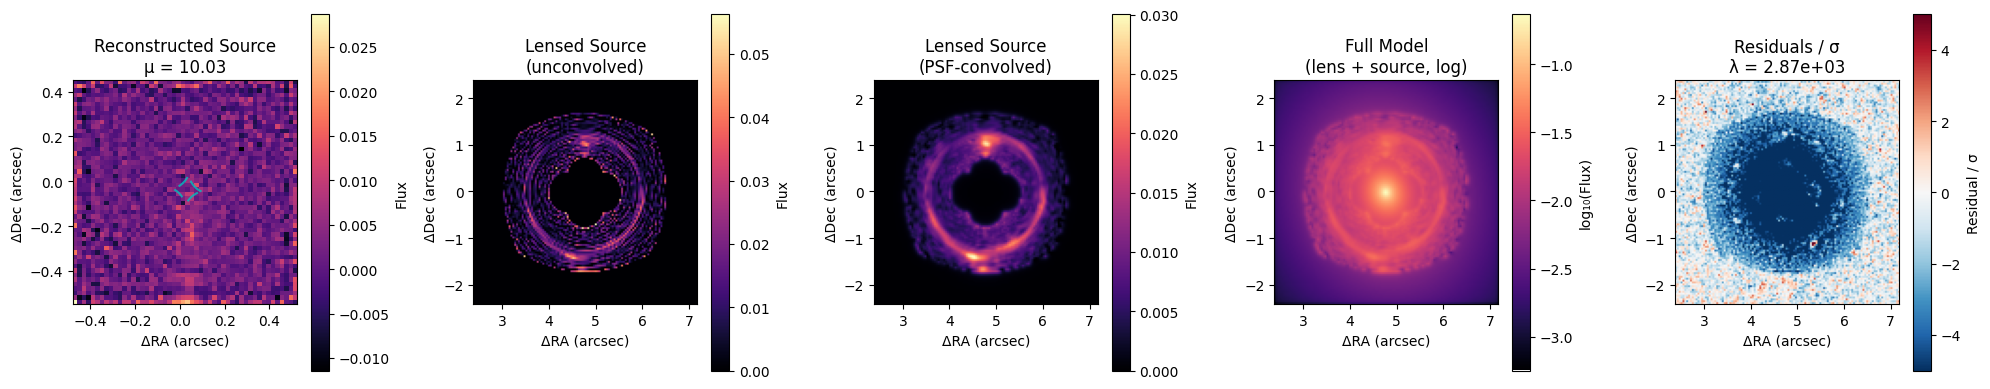

In [17]:
fig = output.plot_reconstruction_overview(lens_name=lens_name, reconstruction_id=reconstruction_id, show_caustics=True)

-1.0746535430619377 reduced X^2 of all evaluated imaging data combined (without degrees of freedom subtracted).
reduced chi^2 of data  0 =  1.0746535430619384


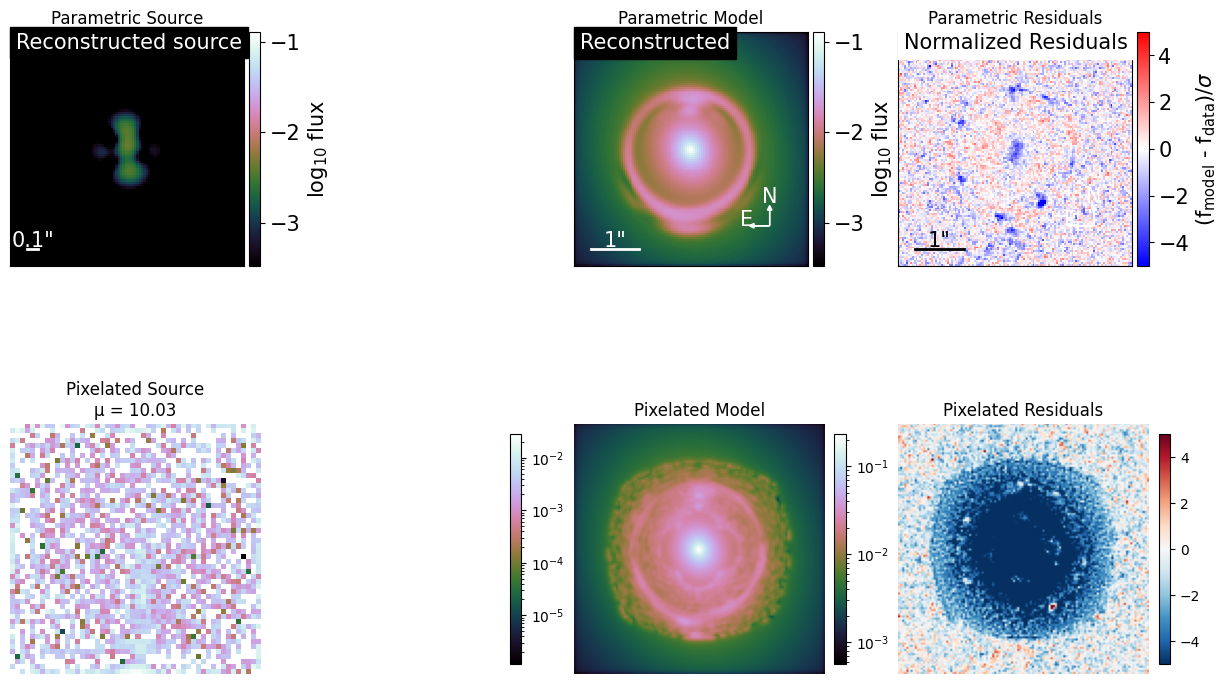

In [18]:
fig = output.plot_reconstruction_comparison(lens_name=lens_name, model_id=model_id, reconstruction_id=reconstruction_id)

-1.0746535430619377 reduced X^2 of all evaluated imaging data combined (without degrees of freedom subtracted).
reduced chi^2 of data  0 =  1.0746535430619384


/data/bwedig/.conda/envs/dolphin/lib/python3.12/site-packages/lenstronomy/Plots/model_band_plot.py:161: RuntimeWarning: invalid value encountered in log10
  np.log10(self._data),


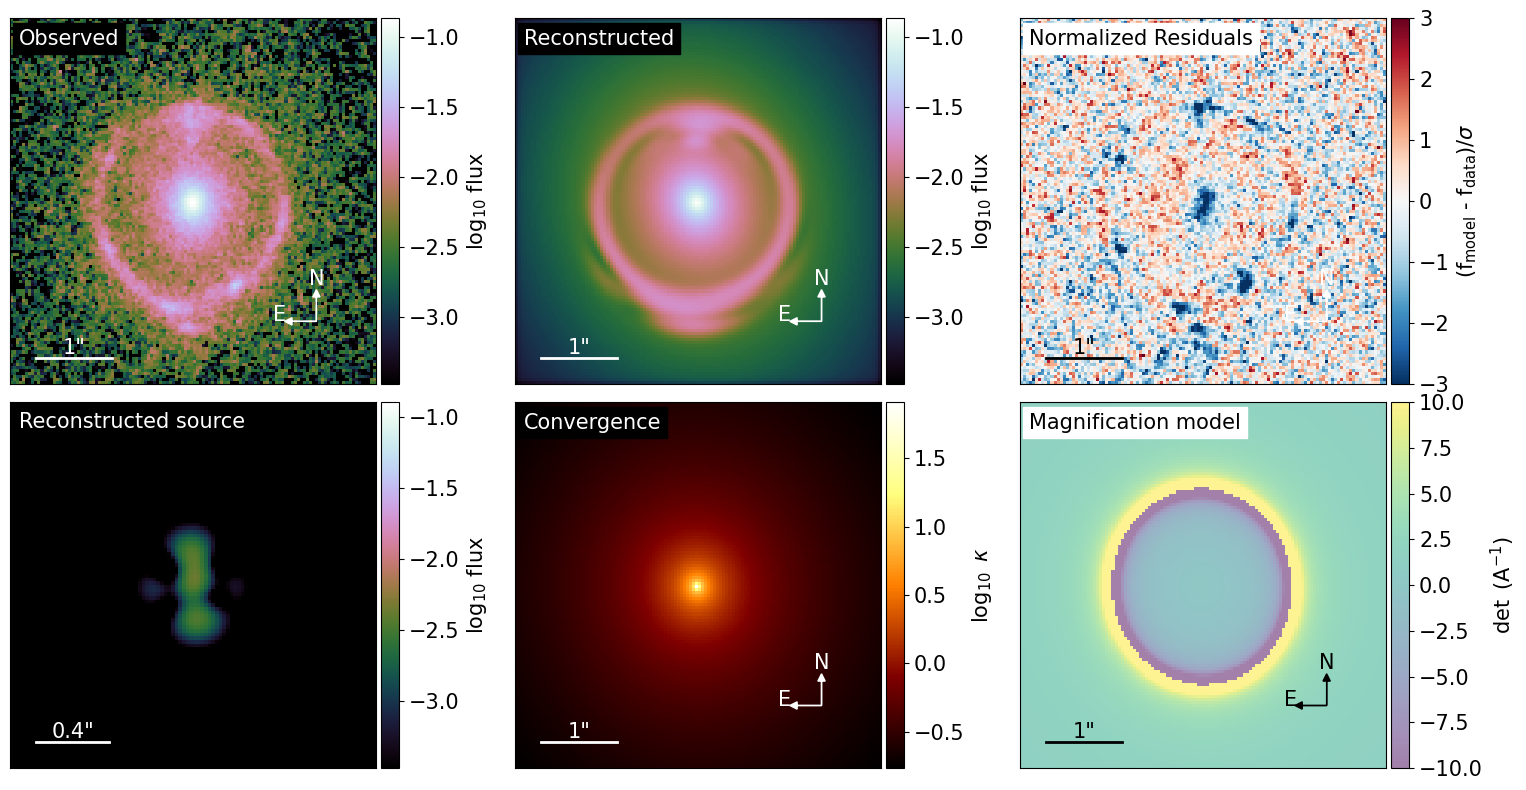

In [19]:
fig = output.plot_model_overview(lens_name=lens_name, model_id=model_id, reconstruction_id=reconstruction_id)